# Memory Agent

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
model=ChatOpenAI(model='gpt-4o-mini',temperature=0)

In [3]:
from pydantic import BaseModel, Field

class Memory(BaseModel):
    content:str=Field(description='The main content of the memory.For example: User expressed interest in learning about French.')
    
class MemoryCollection(BaseModel):
    memories:list[Memory]=Field(description='a list of memories about user')

In [4]:
from trustcall import create_extractor

# Create the extractor
trustcall_extractor=create_extractor(
    model,
    tools=[Memory],
    tool_choice='Memory',
    enable_inserts=True    
)

# Inspect the tool calls made by Trustcall
class Spy:
    # Collect information about the tool calls made by the extractor.
    def __init__(self):
        self.called_tools=[]
    def __call__(self,run):
        q=[run]
        while q:
            r=q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type=='chat_model':
                self.called_tools.append(r.outputs['generations'][0][0]['message']['kwargs']['tool_calls'])

# Initialize the spy
spy=Spy()

# Add the spy as a listener
trustcall_extractor_see_all_tool_calls=trustcall_extractor.with_listeners(on_end=spy)

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# Instruction
instructions='extract the information about user from followig converstaion'

# Conversation
conversation = [HumanMessage(content="Hi, I'm Suman."), 
                AIMessage(content="Nice to meet you, Suman"), 
                HumanMessage(content="This morning I had a nice bike ride in Godda.")]

# Invoke the extractor
result=trustcall_extractor.invoke({'messages':[SystemMessage(content=instructions)]+conversation})
result

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 113, 'total_tokens': 136, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 3.075e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 3.075e-05, 'upstream_inference_prompt_cost': 1.695e-05, 'upstream_inference_completions_cost': 1.38e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_c400bf5046', 'id': 'gen-1787903942-s9ujVhvbxlW9kKXhxfGv', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04761-1c8a-7c60-8ec3-588292d734b5-0', tool_calls=[{'name': 'Memory', 'args': {'conten

In [6]:
# Messages contain the tool calls
for m in result['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_Z4y0jkuh7hbaNgeUG4kD79CL)
 Call ID: call_Z4y0jkuh7hbaNgeUG4kD79CL
  Args:
    content: User's name is Suman and they had a nice bike ride in Godda this morning.


In [7]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content="User's name is Suman and they had a nice bike ride in Godda this morning."


In [8]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_Z4y0jkuh7hbaNgeUG4kD79CL'}


In [9]:
# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name='Memory'
existing_memories=[(str(i),tool_name,memory.model_dump()) for i,memory in enumerate(result['responses'])] if result['responses'] else None
existing_memories

[('0',
  'Memory',
  {'content': "User's name is Suman and they had a nice bike ride in Godda this morning."})]

In [10]:
# Update the conversation
updated_conversation = [
    AIMessage(content="That sounds like a great morning! What did you do afterward?"),
    HumanMessage(content="I had lunch with my family at a restaurant in Godda."),
    AIMessage(content="Nice! Anything else on your mind?"),
    HumanMessage(content="I'm preparing for AI engineering interviews and working on my LangGraph memory system project. I'm also planning to visit Bengaluru this winter.")
]

# Update the instruction
sys_msg = "update the existing memories and create the new ones"

# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor_see_all_tool_calls.invoke({
    "messages": updated_conversation,
    "existing": existing_memories
})
result

{'messages': [AIMessage(content='', additional_kwargs={'updated_docs': {'call_NzqWrsuOj58Hyst14BFvghxq': '0'}}, response_metadata={}, id='7dce5677-75a2-4c91-83c4-914026f06f52', tool_calls=[{'name': 'Memory', 'args': {'content': "User's name is Suman and they had a nice bike ride in Godda this morning. They had lunch with their family at a restaurant in Godda. They are preparing for AI engineering interviews and working on their LangGraph memory system project. They are also planning to visit Bengaluru this winter."}, 'id': 'call_NzqWrsuOj58Hyst14BFvghxq', 'type': 'tool_call'}, {'name': 'Memory', 'args': {'content': 'User is preparing for AI engineering interviews, working on their LangGraph memory system project, and planning to visit Bengaluru this winter.'}, 'id': 'call_Ndqt91Z9CsLjmjgu2RGEEk2B', 'type': 'tool_call'}], invalid_tool_calls=[])],
 'responses': [Memory(content="User's name is Suman and they had a nice bike ride in Godda this morning. They had lunch with their family at a

In [11]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_NzqWrsuOj58Hyst14BFvghxq)
 Call ID: call_NzqWrsuOj58Hyst14BFvghxq
  Args:
    content: User's name is Suman and they had a nice bike ride in Godda this morning. They had lunch with their family at a restaurant in Godda. They are preparing for AI engineering interviews and working on their LangGraph memory system project. They are also planning to visit Bengaluru this winter.
  Memory (call_Ndqt91Z9CsLjmjgu2RGEEk2B)
 Call ID: call_Ndqt91Z9CsLjmjgu2RGEEk2B
  Args:
    content: User is preparing for AI engineering interviews, working on their LangGraph memory system project, and planning to visit Bengaluru this winter.


In [12]:
# Parsed responses
for m in result["responses"]:
    print(m)

content="User's name is Suman and they had a nice bike ride in Godda this morning. They had lunch with their family at a restaurant in Godda. They are preparing for AI engineering interviews and working on their LangGraph memory system project. They are also planning to visit Bengaluru this winter."
content='User is preparing for AI engineering interviews, working on their LangGraph memory system project, and planning to visit Bengaluru this winter.'


In [13]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_NzqWrsuOj58Hyst14BFvghxq', 'json_doc_id': '0'}
{'id': 'call_Ndqt91Z9CsLjmjgu2RGEEk2B'}


In [14]:
# Inspect the tool calls made by Trustcall
spy.called_tools

[[{'name': 'PatchDoc',
   'args': {'json_doc_id': '0',
    'planned_edits': 'Update the memory content to include lunch with family, preparation for AI engineering interviews, work on LangGraph memory system project, and plans to visit Bengaluru this winter.',
    'patches': [{'op': 'replace',
      'path': '/content',
      'value': "User's name is Suman and they had a nice bike ride in Godda this morning. They had lunch with their family at a restaurant in Godda. They are preparing for AI engineering interviews and working on their LangGraph memory system project. They are also planning to visit Bengaluru this winter."}]},
   'id': 'call_NzqWrsuOj58Hyst14BFvghxq',
   'type': 'tool_call'},
  {'name': 'Memory',
   'args': {'content': 'User is preparing for AI engineering interviews, working on their LangGraph memory system project, and planning to visit Bengaluru this winter.'},
   'id': 'call_Ndqt91Z9CsLjmjgu2RGEEk2B',
   'type': 'tool_call'}]]

In [15]:
def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.
    
    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []
    
    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )
    
    return "\n\n".join(result_parts)

# Inspect spy.called_tools to see exactly what happened during the extraction
schema_name = "Memory"
changes = extract_tool_info(spy.called_tools, schema_name)
print(changes)

Document 0 updated:
Plan: Update the memory content to include lunch with family, preparation for AI engineering interviews, work on LangGraph memory system project, and plans to visit Bengaluru this winter.
Added content: User's name is Suman and they had a nice bike ride in Godda this morning. They had lunch with their family at a restaurant in Godda. They are preparing for AI engineering interviews and working on their LangGraph memory system project. They are also planning to visit Bengaluru this winter.

New Memory created:
Content: {'content': 'User is preparing for AI engineering interviews, working on their LangGraph memory system project, and planning to visit Bengaluru this winter.'}


## Creating an agent

In [16]:
from typing import TypedDict, Literal

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'todo', 'instructions']

## Graph definition 

In [17]:
import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
from typing import Optional
from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

from langchain_openai import ChatOpenAI

In [18]:
# profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    connections: list[str] = Field(
        description="Personal connection of the user, such as family members, friends, or coworkers",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has", 
        default_factory=list
    )

In [19]:
# ToDo schema
class ToDo(BaseModel):
    task: str = Field(description="The task to be completed.")
    time_to_complete: Optional[int] = Field(description="Estimated time to complete the task (minutes).")
    deadline: Optional[datetime] = Field(
        description="When the task needs to be completed by (if applicable)",
        default=None
    )
    solutions: list[str] = Field(
        description="List of specific, actionable solutions (e.g., specific ideas, service providers, or concrete options relevant to completing the task)",
        min_items=1,
        default_factory=list
    )
    status: Literal["not started", "in progress", "done", "archived"] = Field(
        description="Current status of the task",
        default="not started"
    )

In [20]:
# Create the Trustcall extractor for updating the user profile 
profile_extractor = create_extractor(
    model,
    tools=[Profile],
    tool_choice="Profile",
)

# Create the Trustcall extractor for updating and adding in the todo list 
todo_extractor = create_extractor(
    model,
    tools=[ToDo],
    tool_choice="ToDo",
    enable_inserts=True,
)

In [21]:
# Chatbot instruction for choosing what to update and what tools to call 
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. 

You are designed to be a companion to a user, helping them keep track of their ToDo list.

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them) 
2. The user's ToDo list
3. General instructions for updating the ToDo list

Here is the current User Profile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current ToDo List (may be empty if no tasks have been added yet):
<todo>
{todo}
</todo>

Here are the current user-specified preferences for updating the ToDo list (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Reason carefully about the user's messages as presented below. 

2. Decide whether any of the your long-term memory should be updated:
- If personal information was provided about the user, update the user's profile by calling UpdateMemory tool with type `user`
- If tasks are mentioned, update the ToDo list by calling UpdateMemory tool with type `todo`
- If the user has specified preferences for how to update the ToDo list, update the instructions by calling UpdateMemory tool with type `instructions`

3. Tell the user that you have updated your memory, if appropriate:
- Do not tell the user you have updated the user's profile
- Tell the user them when you update the todo list
- Do not tell the user that you have updated instructions

4. Err on the side of updating the todo list. No need to ask for explicit permission.

5. Respond naturally to user user after a tool call was made to save memories, or if no tool call was made."""

def my_task_manager(state:MessagesState,config:RunnableConfig,store:BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""

     # Get the user ID from the config
    user_id=config['configurable']['user_id']

     # Retrieve profile memory from the store
    namespace=('profile',user_id)
    memories=store.search(namespace)
    if memories:
        user_profile=memories[0].value
    else:
        user_profile=None

    # Retrieve task memory from the store
    namespace=('todo',user_id)
    memories=store.search(namespace)
    todo='\n'.join(f"{mem.value}" for mem in memories)

    # Retrieve custom instructions
    namespace=('instructions',user_id)
    memories=store.search(namespace)
    if memories:
        instructions=memories[0].value['memory']
    else:
        instructions=""

    sys_msg=MODEL_SYSTEM_MESSAGE.format(user_profile=user_profile,todo=todo,instructions=instructions)

    # Respond using memory as well as the chat history
    response=model.bind_tools([UpdateMemory],parallel_tool_calls=False).invoke([SystemMessage(content=sys_msg)]+state['messages'])
    # print(response)
    # print(state['messages'])
    return {'messages':[response]}

In [22]:
# Conditional edge
def route_messages(state:MessagesState,config:RunnableConfig,store:BaseStore) -> Literal[END,"update_profile",'update_todos','update_instructions']:

    """Reflect on the memories and chat history to decide whether to update the memory collection."""

    messages=state['messages'][-1]
    if len(messages.tool_calls)==0:
        return END
    else:
        tool_call=messages.tool_calls[0]
        if tool_call['args']['update_type']=='user':
            return 'update_profile'
        elif tool_call['args']['update_type']=='todo':
                    return 'update_todos'
        elif tool_call['args']['update_type']=='instructions':
                    return 'update_instructions'
        else:
             raise ValueError

In [23]:
# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously.

System Time: {time}"""

In [24]:
def update_profile(state:MessagesState,config:RunnableConfig,store:BaseStore):

    """Reflect on the chat history and update the memory collection."""

    # Get the user ID from the config
    user_id=config['configurable']['user_id']

    # Define the namespace for the memories
    namespace=('profile',user_id)

    # Retrieve the most recent memories for context
    existing_items=store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name='Profile'
    existing_memories=(
    [(existing_item.key,tool_name,existing_item.value) for existing_item in existing_items]
    ) if existing_items else None

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)]+state['messages'][:-1]))

    # Invoke the extractor
    result=profile_extractor.invoke({'messages':updated_messages,'existing':existing_memories})
    # print(result)

    # Save the memories from Trustcall to the store
    for r,rmeta in zip(result['responses'],result['response_metadata']):
        store.put(namespace,rmeta.get('json_doc_id',str(uuid.uuid4())),r.model_dump(mode='json'))

    tool_calls=state['messages'][-1].tool_calls
    return {'messages':[{'role':'tool','content':'updated_profile','tool_call_id':tool_calls[0]['id']}]}

In [25]:
def update_todos(state:MessagesState,config:RunnableConfig,store:BaseStore):

    """Reflect on the chat history and update the memory collection."""

    # Get the user ID from the config
    user_id=config['configurable']['user_id']

    # Define the namespace for the memories
    namespace=('todo',user_id)

    # Retrieve the most recent memories for context
    existing_items=store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name='ToDo'
    existing_memories=(
    [(existing_item.key,tool_name,existing_item.value) for existing_item in existing_items]
    ) if existing_items else None

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)]+state['messages'][:-1]))

    # Initialize the spy for visibility into the tool calls made by Trustcall
    spy = Spy()

    # Invoke the extractor
    result=todo_extractor.with_listeners(on_end=spy).invoke({'messages':updated_messages,'existing':existing_memories})

    # Save the memories from Trustcall to the store
    for r,rmeta in zip(result['responses'],result['response_metadata']):
        store.put(namespace,rmeta.get('json_doc_id',str(uuid.uuid4())),r.model_dump(mode='json'))

    # Respond to the tool call made in task_mAIstro, confirming the update
    tool_calls=state['messages'][-1].tool_calls

    # Extract the changes made by Trustcall and add the the ToolMessage returned to task_mAIstro
    todo_update_msg=extract_tool_info(spy.called_tools,tool_name)
    return {'messages':[{'role':'tool','content':todo_update_msg,'tool_call_id':tool_calls[0]['id']}]}

In [26]:
# Instructions for updating the ToDo list
CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update ToDo list items. 

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
</current_instructions>"""

In [27]:
def update_instructions(state:MessagesState,config:RunnableConfig,store:BaseStore):

    """Reflect on the chat history and update the memory collection."""

    # Get the user ID from the config
    user_id=config['configurable']['user_id']
    namespace=('instructions',user_id)
    existing_items=store.get(namespace,'user_instructions')

    # Format the memory in the system prompt
    sys_msg=CREATE_INSTRUCTIONS.format(current_instructions=existing_items.value['memory'] if existing_items else None)
    new_memory=model.invoke([SystemMessage(content=sys_msg)]+state['messages'][:-1]+[HumanMessage(content="Please update the instructions based on the conversation")])

    # Overwrite the existing memory in the store 
    key='user_instructions'
    store.put(namespace,key,{'memory':new_memory.content})

    tool_calls=state['messages'][-1].tool_calls
    return {'messages':[{'role':'tool','content':'updated_instructions','tool_call_id':tool_calls[0]['id']}]}

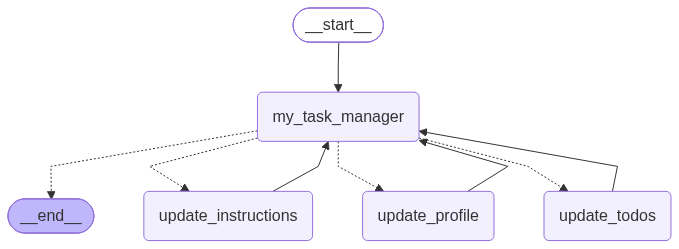

In [28]:
# Create the graph + all nodes
builder=StateGraph(MessagesState)

# Define the flow of the memory extraction process
builder.add_node(my_task_manager)
builder.add_node(update_profile)
builder.add_node(update_todos)
builder.add_node(update_instructions)

builder.add_edge(START,'my_task_manager')
builder.add_conditional_edges('my_task_manager',route_messages)
builder.add_edge('update_profile','my_task_manager')
builder.add_edge('update_todos','my_task_manager')
builder.add_edge('update_instructions','my_task_manager')

# Store for long-term (across-thread) memory
across_thread_memory=InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory=MemorySaver()

# We compile the graph with the checkpointer and store
graph=builder.compile(checkpointer=within_thread_memory,store=across_thread_memory)

# view
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [29]:
config = {"configurable": {"thread_id": "1", "user_id": "Suman"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="My name is suman. I live in India. I am 24 years old")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

My name is suman. I live in India. I am 24 years old
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_4hvj4F73hJx9oLfvLBwIJGKX)
 Call ID: call_4hvj4F73hJx9oLfvLBwIJGKX
  Args:
    update_type: user
================================= Tool Message =================================

updated_profile
================================== Ai Message ==================================

I've noted your age as well. If there's anything else you'd like to share or update, feel free to let me know!


In [30]:
# User input for a ToDo
input_messages = [HumanMessage(content="I want to find best Gym in India")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I want to find best Gym in India
================================== Ai Message ==================================

Finding the best gym can depend on various factors like location, facilities, and personal preferences. Here are a few popular gyms in India that are often recommended:

1. **Gold's Gym** - Known for its extensive range of equipment and fitness classes.
2. **Anytime Fitness** - Offers 24/7 access and is available in many locations across India.
3. **Talwalkars** - One of the oldest gym chains in India, offering a variety of fitness programs.
4. **Fitness First** - Known for its premium facilities and personal training options.
5. **Snap Fitness** - Offers flexible membership options and is open 24/7.

You might want to check reviews and visit a few to see which one fits your needs best. Would you like me to add "Find the best gym in India" to your ToDo list?


In [31]:
# User input to update instructions for creating ToDos
input_messages = [HumanMessage(content="When creating or updating ToDo items, include specific location")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

When creating or updating ToDo items, include specific location
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_6pkUd1QpzCg7jPkhzCwfW50p)
 Call ID: call_6pkUd1QpzCg7jPkhzCwfW50p
  Args:
    update_type: instructions
================================= Tool Message =================================

updated_instructions
================================== Ai Message ==================================

I've updated the instructions to include specific location details when creating or updating ToDo items. Now, would you like me to add "Find the best gym in India" to your ToDo list? If so, please specify a location!


In [ ]:
# Check for updated instructions
user_id = "Suman"

# Search 
for memory in across_thread_memory.search(("instructions", user_id)):
    print(memory.value)